In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import r2_score,mean_squared_error

In [3]:
from sklearn.datasets import load_diabetes

data=load_diabetes()

In [5]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [8]:
X=data.data
y=data.target

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=50)

In [10]:
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)
score=r2_score(y_test,y_pred)
print("R2 score is: ",score)
print("MSE is :",mean_squared_error(y_test,y_pred))
print("RMSE is :",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 score is:  0.523404931810618
MSE is : 2650.959675581209
RMSE is : 51.487471054434295


In [11]:
ridge=Ridge(alpha=0.001,solver="cholesky")
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.5253100204496925

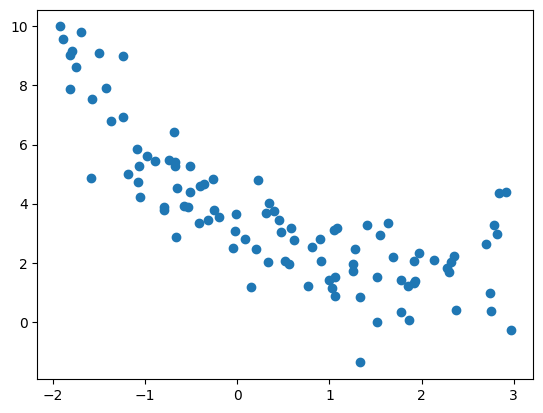

In [18]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

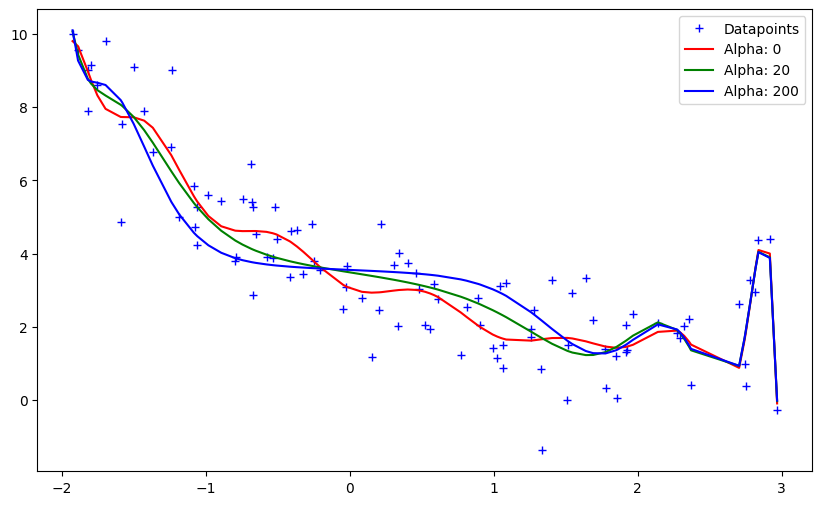

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

In [13]:
data=pd.read_csv(r"placement.csv")
X_train1,X_test1,y_train1,y_test1=train_test_split(data[['cgpa']],data['package'],test_size=0.2,random_state=42)

In [37]:
# Simple linear regression

class RidgeRegression:
    def __init__(self,alpha):
        self.coef=None
        self.intercept=None
        self.alpha=alpha
    
    def fit(self,X_train,y_train):
        X_train = X_train.values.ravel()
        y_train = y_train.values
        X_bar=X_train.mean()
        y_bar=y_train.mean()
        n=np.sum((X_train-X_bar)*(y_train-y_bar))
        d=np.sum((X_train-X_bar)**2)
        self.coef=n/(d+self.alpha)

        self.intercept= y_bar-(self.coef*X_bar)
        return self.coef,self.intercept
    
    def predict(self,X_test):
        X_test = X_test.values.ravel()
        return self.intercept + (self.coef*X_test)

In [38]:
r1=RidgeRegression(10)

r1.fit(X_train1,y_train1)
y_pred=r1.predict(X_test1)

score=r2_score(y_test1,y_pred)
score

0.7751638438001816

In [39]:
lr=LinearRegression()

lr.fit(X_train1,y_train1)
y_pred1=lr.predict(X_test1)

score1=r2_score(y_test1,y_pred1)
score1

0.7730984312051673

In [46]:
ridge=Ridge(alpha=10,solver='cholesky')
ridge.fit(X_train1,y_train1)

y_pred2=ridge.predict(X_test1)

score2=r2_score(y_test1,y_pred2)
score2

0.7751638438001816

In [47]:
lr.coef_,lr.intercept_

(array([0.57425647]), np.float64(-1.0270069374542108))

In [48]:
ridge.coef_,ridge.intercept_

(array([0.54540675]), np.float64(-0.8249038386410339))

In [42]:
r1.coef,r1.intercept

(np.float64(0.5454067539055416), np.float64(-0.8249038386410339))

In [49]:
# multiple linear regression

class Ridge:
    def __init__(self,alpha):
        self.coef=None
        self.intercept=None
        self.alpha=alpha
    
    def fit(self,X_train,y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        X_train=np.insert(X_train,0,1,axis=1)
        I=np.identity(X_train.shape[1])
        I[0,0]=0

        self.coef=np.linalg.inv(np.dot(X_train.T,X_train)+I*self.alpha).dot(X_train.T).dot(y_train)
        self.intercept=self.coef[0]
        self.coef=self.coef[1:]
        
        return self.coef,self.intercept
    
    def predict(self,X_test):
        return self.intercept + np.dot(X_test,self.coef)

In [50]:
r2=Ridge(0.001)
r2.fit(X_train,y_train)

y_pred=r2.predict(X_test)
score=r2_score(y_test,y_pred)
score

0.5253100204496931

In [51]:
r2.coef

array([  41.26657024, -254.83802689,  500.12531336,  341.64943807,
       -876.10599516,  564.08817182,  122.18270983,  176.48885632,
        789.26237908,   26.357918  ])

In [52]:
ridge.coef_

array([0.54540675])